In [25]:
# %%
import re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

import nltk
from nltk.stem import WordNetLemmatizer, PorterStemmer

In [10]:
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /home/vrishaan/nltk_data...
[nltk_data] Downloading package omw-1.4 to /home/vrishaan/nltk_data...


True

In [16]:
DATA_PATH = Path("data/amazon.csv") 

In [17]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(word) for word in text.split()])

def stem_text(text):
    return " ".join([stemmer.stem(word) for word in text.split()])

In [18]:
def load_data(path):
    if path.name == "amazon.csv":
        df = pd.read_csv(path, header=None, names=["label", "title", "review"])
        df = df.dropna(subset=["label", "review"])
        df["label"] = df["label"].map({1: "neg", 2: "pos"})
        df["text"] = df["title"].fillna("") + " " + df["review"].fillna("")
    else:
        df = pd.read_csv(path)
        df = df.dropna(subset=["review", "label"])
        df["text"] = df["review"].astype(str)

    return df

df = load_data(DATA_PATH)
print("Total samples:", len(df))
df.head()

Total samples: 400000


,label,title,review,text
0,pos,Great CD,My lovely Pat has one of the GREAT voices of h...,Great CD My lovely Pat has one of the GREAT vo...
1,pos,One of the best game music soundtracks - for a...,Despite the fact that I have only played a sma...,One of the best game music soundtracks - for a...
2,neg,Batteries died within a year ...,I bought this charger in Jul 2003 and it worke...,Batteries died within a year ... I bought this...
3,pos,"works fine, but Maha Energy is better",Check out Maha Energy's website. Their Powerex...,"works fine, but Maha Energy is better Check ou..."
4,pos,Great for the non-audiophile,Reviewed quite a bit of the combo players and ...,Great for the non-audiophile Reviewed quite a ...


In [19]:
df["clean"] = df["text"].apply(clean_text)
df["lemma"] = df["clean"].apply(lemmatize_text)
df["stem"] = df["clean"].apply(stem_text)

In [21]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=25,
    stratify=df["label"]
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 320000
Test size: 80000


In [22]:
PROCESSED_PATH = Path("data/processed_reviews.csv")

df.to_csv(PROCESSED_PATH, index=False)

print("Saved processed dataset to:", PROCESSED_PATH)

Saved processed dataset to: data/processed_reviews.csv


In [23]:
def train_and_evaluate(train_df, test_df, column):
    vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))

    X_train = vectorizer.fit_transform(train_df[column])
    X_test = vectorizer.transform(test_df[column])

    model = MultinomialNB()
    model.fit(X_train, train_df["label"])

    preds = model.predict(X_test)

    acc = accuracy_score(test_df["label"], preds)
    cm = confusion_matrix(test_df["label"], preds, labels=["neg", "pos"])

    print(f"\n===== {column.upper()} =====")
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Classification Report:\n",
          classification_report(test_df["label"], preds, digits=3))

    return acc

In [24]:
results = {}

results["clean"] = train_and_evaluate(train_df, test_df, "clean")
results["lemma"] = train_and_evaluate(train_df, test_df, "lemma")
results["stem"] = train_and_evaluate(train_df, test_df, "stem")

results


===== CLEAN =====
Accuracy: 0.8766375
Confusion Matrix:
 [[35443  4557]
 [ 5312 34688]]
Classification Report:
               precision    recall  f1-score   support

         neg      0.870     0.886     0.878     40000
         pos      0.884     0.867     0.875     40000

    accuracy                          0.877     80000
   macro avg      0.877     0.877     0.877     80000
weighted avg      0.877     0.877     0.877     80000


===== LEMMA =====
Accuracy: 0.87295
Confusion Matrix:
 [[35396  4604]
 [ 5560 34440]]
Classification Report:
               precision    recall  f1-score   support

         neg      0.864     0.885     0.874     40000
         pos      0.882     0.861     0.871     40000

    accuracy                          0.873     80000
   macro avg      0.873     0.873     0.873     80000
weighted avg      0.873     0.873     0.873     80000


===== STEM =====
Accuracy: 0.8751375
Confusion Matrix:
 [[35789  4211]
 [ 5778 34222]]
Classification Report:
           

{'clean': 0.8766375, 'lemma': 0.87295, 'stem': 0.8751375}

In [26]:
best_method = max(results, key=results.get)
print("Best method:", best_method)

vectorizer = TfidfVectorizer(stop_words="english", ngram_range=(1, 2))

X_train = vectorizer.fit_transform(train_df[best_method])
X_test = vectorizer.transform(test_df[best_method])

model = MultinomialNB()
model.fit(X_train, train_df["label"])

preds = model.predict(X_test)

Best method: clean


In [27]:
acc = accuracy_score(test_df["label"], preds)
cm = confusion_matrix(test_df["label"], preds, labels=["neg", "pos"])

print("Final Accuracy:", acc)
print("Confusion Matrix:\n", cm)
print("Classification Report:\n",
      classification_report(test_df["label"], preds, digits=3))

Final Accuracy: 0.8766375
Confusion Matrix:
 [[35443  4557]
 [ 5312 34688]]
Classification Report:
               precision    recall  f1-score   support

         neg      0.870     0.886     0.878     40000
         pos      0.884     0.867     0.875     40000

    accuracy                          0.877     80000
   macro avg      0.877     0.877     0.877     80000
weighted avg      0.877     0.877     0.877     80000



In [29]:
MODEL_PATH = Path("models/evaluation_model.pkl")
MODEL_PATH.parent.mkdir(exist_ok=True)

joblib.dump({
    "vectorizer": vectorizer,
    "model": model,
    "method": best_method
}, MODEL_PATH)

print("Evaluation model saved ")

Evaluation model saved 


In [30]:
data = joblib.load("models/evaluation_model.pkl")

vectorizer = data["vectorizer"]
model = data["model"]
method = data["method"]

print("Model loaded ✅")

Model loaded ✅


In [31]:
X_test = vectorizer.transform(test_df[method])

y_true = test_df["label"]
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8766375


In [32]:
print(classification_report(y_true, y_pred, digits=3))

              precision    recall  f1-score   support

         neg      0.870     0.886     0.878     40000
         pos      0.884     0.867     0.875     40000

    accuracy                          0.877     80000
   macro avg      0.877     0.877     0.877     80000
weighted avg      0.877     0.877     0.877     80000



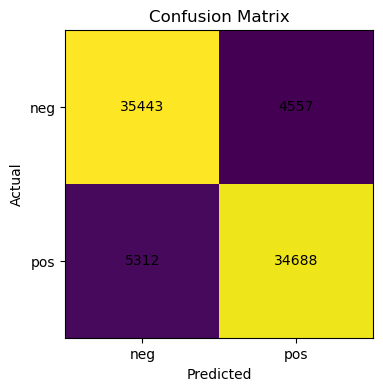

In [33]:

cm = confusion_matrix(y_true, y_pred, labels=["neg", "pos"])

plt.figure(figsize=(5, 4))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["neg", "pos"])
plt.yticks([0, 1], ["neg", "pos"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [34]:
from sklearn.metrics import roc_curve, auc

# Convert labels to binary
y_true_bin = y_true.map({"neg": 0, "pos": 1})

# Get probabilities
y_probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_true_bin, y_probs)
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9476621993750001


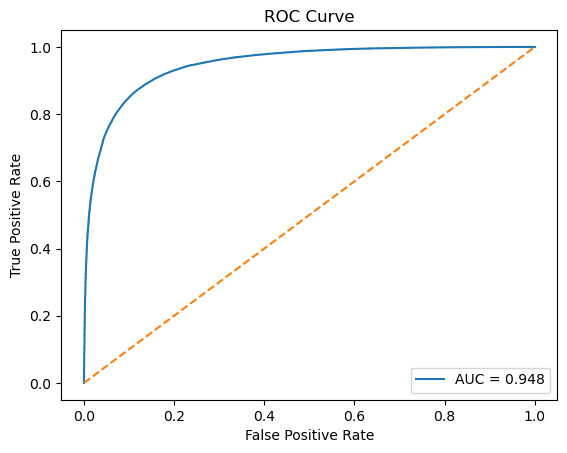

In [35]:
plt.figure()

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

In [36]:
metrics = {
    "accuracy": accuracy,
    "auc": roc_auc,
    "confusion_matrix": cm.tolist()
}

with open("outputs/final_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved")

Metrics saved
